In [1]:
import os
import cv2
import numpy as np
import random
from pathlib import Path

def extract_patches(
    data_dir: str,
    output_dir: str,
    patch_size: int = 256,
    num_images: int = 0,
    cells_per_img: int = 4,
    bg_per_img: int = 4,
    cell_margin: int = 5
):
    bg_dir = os.path.join(output_dir, "bg_patches")
    cell_dir = os.path.join(output_dir, "cell_patches")
    os.makedirs(bg_dir, exist_ok=True)
    os.makedirs(cell_dir, exist_ok=True)

    original_dir = os.path.join(data_dir, "original")
    mask_dir = os.path.join(data_dir, "mask")

    img_dict = {p.stem: p for p in Path(original_dir).glob("*.png")}
    mask_dict = {p.stem: p for p in Path(mask_dir).glob("*.png")}
    common = sorted(set(img_dict.keys()) & set(mask_dict.keys()))

    if num_images > 0:
        common = common[:num_images]

    bg_saved, cell_saved = 0, 0

    for stem in common:
        img = cv2.imread(str(img_dict[stem]))
        mask = cv2.imread(str(mask_dict[stem]), cv2.IMREAD_GRAYSCALE)
        if img is None or mask is None:
            continue

        h, w = img.shape[:2]

        # Поиск всех клеток на маске
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
        valid_cells = [i for i in range(1, num_labels) if stats[i, cv2.CC_STAT_AREA] >= 150]
        random.shuffle(valid_cells)

        # Нарезка клеток
        cell_found = 0
        for idx in valid_cells:
            if cell_found >= cells_per_img:
                break

            x, y, cw, ch = cv2.boundingRect((labels == idx).astype(np.uint8))

            x1 = max(0, x - cell_margin)
            y1 = max(0, y - cell_margin)
            x2 = min(w, x + cw + cell_margin)
            y2 = min(h, y + ch + cell_margin)

            if x1 < 0 or y1 < 0 or x2 > w or y2 > h:
                continue

            sub_mask = mask[y1:y2, x1:x2].copy()
            _, _, sub_stats, _ = cv2.connectedComponentsWithStats(sub_mask, connectivity=8)
            if sum(1 for k in range(1, len(sub_stats)) if sub_stats[k, cv2.CC_STAT_AREA] >= 150) != 1:
                continue

            # Вырезаем патч и обнуляем фон (делаем черным)
            patch = img[y1:y2, x1:x2].copy()
            patch[sub_mask == 0] = 0

            cv2.imwrite(os.path.join(cell_dir, f"cell_{cell_saved:05d}.png"), patch)
            cell_saved += 1
            cell_found += 1

        # Нарезка фона
        bg_found = 0
        attempts = 0
        while bg_found < bg_per_img and attempts < 300:
            y = random.randint(0, max(0, h - patch_size))
            x = random.randint(0, max(0, w - patch_size))
            p_mask = mask[y:y+patch_size, x:x+patch_size]
            if np.sum(p_mask > 0) == 0:
                p_img = img[y:y+patch_size, x:x+patch_size].copy()
                cv2.imwrite(os.path.join(bg_dir, f"bg_{bg_saved:05d}.png"), p_img)
                bg_saved += 1
                bg_found += 1
            attempts += 1

    print(f"Сохранено: {bg_saved} фоновых, {cell_saved} клеточных патчей.")

In [2]:
import torch
import numpy as np
import cv2
import random
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
import torchvision.transforms as transforms

class BloodCellDataset(Dataset):
    def __init__(
        self,
        bg_dir: str,
        cell_dir: str,
        img_size: tuple = (256, 256),
        dataset_size: int = 2000,
        max_cells: int = 8,
        use_synthetic: bool = True
    ):
        self.img_size = img_size
        self.dataset_size = dataset_size
        self.max_cells = max_cells
        self.use_synthetic = use_synthetic

        self.bg_paths = list(Path(bg_dir).glob("*.png"))
        self.cell_paths = list(Path(cell_dir).glob("*.png"))
        self.has_bg = len(self.bg_paths) > 0
        self.has_cells = len(self.cell_paths) > 0

    def __len__(self):
        return self.dataset_size

    def _synth_bg(self):
        color = np.random.randint(220, 255, 3)
        bg = np.full((self.img_size[1], self.img_size[0], 3), color, dtype=np.uint8)
        noise = np.random.normal(0, 6, bg.shape).astype(np.int16)
        return np.clip(bg.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    def _synth_cell(self):
        size = random.randint(20, 50)
        cell = np.zeros((size, size, 3), dtype=np.uint8)
        center = (size // 2, size // 2)
        color = (random.randint(70, 130), random.randint(30, 70), random.randint(30, 70))
        cv2.circle(cell, center, size//2 - 2, color, -1)
        noise = np.random.normal(0, 4, cell.shape).astype(np.int16)
        return np.clip(cell.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    def __getitem__(self, idx):
        # 1. Формирование фона
        if self.has_bg and random.random() > 0.3:
            canvas = cv2.resize(cv2.imread(str(random.choice(self.bg_paths))), self.img_size)
        else:
            canvas = self._synth_bg()

        # 2. Наложение клеток (прямое альфа-наложение, чёрный фон = прозрачный)
        num_cells = random.randint(0, self.max_cells)
        for _ in range(num_cells):
            if self.has_cells and random.random() > 0.4:
                cell = cv2.imread(str(random.choice(self.cell_paths)))
                scale = random.uniform(0.4, 0.9)
                cell = cv2.resize(cell, (int(cell.shape[1]*scale), int(cell.shape[0]*scale)))
            else:
                cell = self._synth_cell()

            h, w = cell.shape[:2]
            x = random.randint(0, max(0, self.img_size[0] - w))
            y = random.randint(0, max(0, self.img_size[1] - h))

            # Маска прозрачности: пиксели > 30 считаются клеткой (alpha=1), остальные фоном (alpha=0)
            gray = cv2.cvtColor(cell, cv2.COLOR_BGR2GRAY)
            _, mask = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
            mask = mask.astype(np.float32) / 255.0

            # Расширяем маску до 3 каналов для поканального умножения
            mask_3d = np.stack([mask] * 3, axis=-1)

            # Прямое альфа-наложение: result = bg*(1-alpha) + cell*alpha
            roi = canvas[y:y+h, x:x+w].astype(np.float32)
            cell_f = cell.astype(np.float32)
            blended = roi * (1 - mask_3d) + cell_f * mask_3d
            canvas[y:y+h, x:x+w] = np.clip(blended, 0, 255).astype(np.uint8)

        # 3. Постпроцессинг
        noise = np.random.normal(0, 4, canvas.shape).astype(np.int16)
        canvas = np.clip(canvas.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        canvas = cv2.GaussianBlur(canvas, (3, 3), 0.5)


        aug_pipeline = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.RandomApply([transforms.RandomRotation(degrees=7)], p=0.25),
        ])
        canvas_rgb = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
        canvas_pil = Image.fromarray(canvas_rgb)
        canvas = cv2.cvtColor(np.array(aug_pipeline(canvas_pil)), cv2.COLOR_RGB2BGR)


        # 4. Конвертация в тензор
        img_tensor = torch.from_numpy(canvas.transpose(2, 0, 1)).float() / 255.0
        return img_tensor, num_cells

Сохранено: 1683 фоновых, 4235 клеточных патчей.


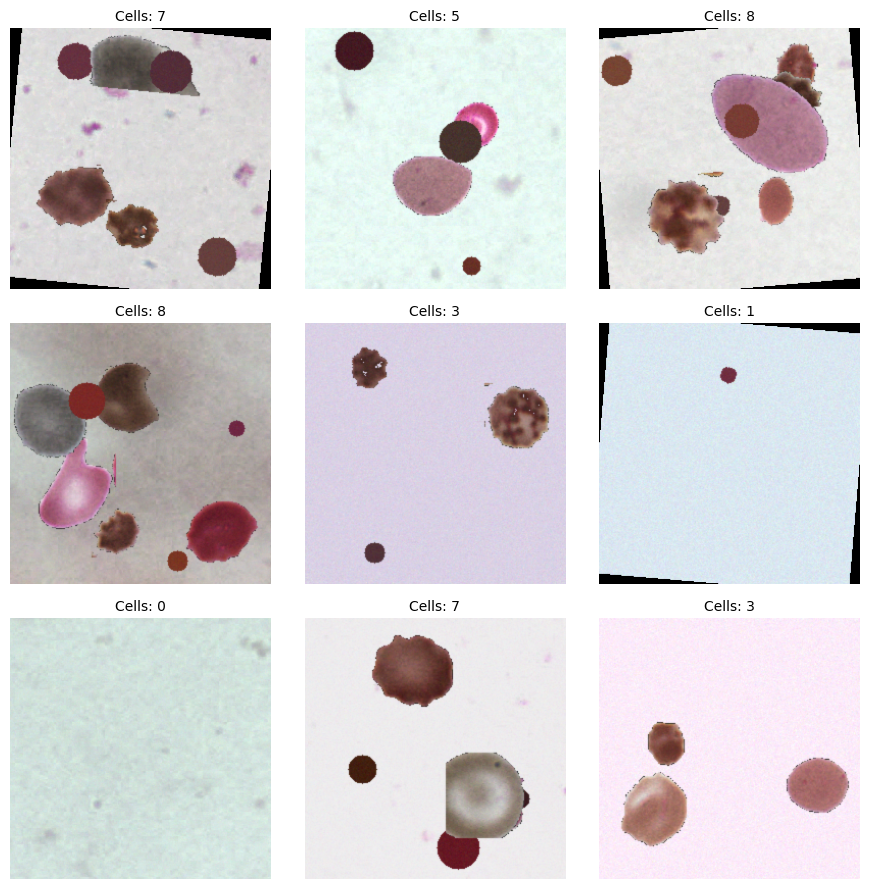

In [3]:
import matplotlib.pyplot as plt
import torch
import os

DATA_ROOT = "./blood_cells_dataset/train"
PATCHES_DIR = "./blood_cells_patches"

extract_patches(
    data_dir=DATA_ROOT,
    output_dir=PATCHES_DIR,
    num_images=0,
    cells_per_img=4,
    bg_per_img=4
)

dataset = BloodCellDataset(
    bg_dir=os.path.join(PATCHES_DIR, "bg_patches"),
    cell_dir=os.path.join(PATCHES_DIR, "cell_patches"),
    img_size=(256, 256),
    dataset_size=2000,
    max_cells=8
)

fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, ax in enumerate(axes.flat):
    idx = torch.randint(0, len(dataset), (1,)).item()
    img, count = dataset[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(f"Cells: {count}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [4]:
save_dir = "./generated_samples_manual_check"
os.makedirs(save_dir, exist_ok=True)

num_samples_to_save = 1500
for i in range(num_samples_to_save):
    img, count = dataset[i]

    # Корректная конвертация тензора в изображение для сохранения
    img_np = (img.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
    img_bgr = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    save_path = os.path.join(save_dir, f"sample_{i:04d}_count_{count}.png")
    cv2.imwrite(save_path, img_bgr)

    if (i + 1) % 300 == 0:
        print(f"Сохранено {i + 1} из {num_samples_to_save} изображений")

print(f"Готово. {num_samples_to_save} изображений сохранено в {save_dir}")

Сохранено 300 из 1500 изображений
Сохранено 600 из 1500 изображений
Сохранено 900 из 1500 изображений
Сохранено 1200 из 1500 изображений
Сохранено 1500 из 1500 изображений
Готово. 1500 изображений сохранено в ./generated_samples_manual_check
